In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df=pd.read_csv('dubai_properties.csv')
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73742 entries, 0 to 73741
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Address                 73742 non-null  object 
 1   Rent                    73742 non-null  int64  
 2   Beds                    73742 non-null  int64  
 3   Baths                   73742 non-null  int64  
 4   Type                    73742 non-null  object 
 5   Area_in_sqft            73742 non-null  int64  
 6   Rent_per_sqft           73742 non-null  float64
 7   Rent_category           73742 non-null  object 
 8   Frequency               73742 non-null  object 
 9   Furnishing              73742 non-null  object 
 10  Purpose                 73742 non-null  object 
 11  Posted_date             73742 non-null  object 
 12  Age_of_listing_in_days  73742 non-null  int64  
 13  Location                73742 non-null  object 
 14  City                    73742 non-null

In [3]:
df_filtered=df[['Rent', 'Beds', 'Baths', 'Type', 'Area_in_sqft', 'Furnishing', 'Location', 'City',]].copy()
df_filtered=df_filtered[df_filtered['Rent']>0]
df_filtered = df_filtered.dropna(subset=['Beds', 'Baths', 'Type', 'Area_in_sqft', 'Furnishing', 'Location', 'City'])
df_filtered

,Rent,Beds,Baths,Type,Area_in_sqft,Furnishing,Location,City
0,124000,3,4,Apartment,1785,Unfurnished,Al Reem Island,Abu Dhabi
1,140000,3,4,Apartment,1422,Unfurnished,Yas Island,Abu Dhabi
2,99000,2,3,Apartment,1314,Furnished,Al Raha Beach,Abu Dhabi
3,220000,3,4,Penthouse,3843,Unfurnished,Al Reem Island,Abu Dhabi
4,350000,5,7,Villa,6860,Unfurnished,Yas Island,Abu Dhabi
...,...,...,...,...,...,...,...,...
73737,14000,0,1,Apartment,419,Unfurnished,Al Salamah,Umm Al Quwain
73738,14000,0,1,Apartment,500,Unfurnished,Umm Al Quwain Marina,Umm Al Quwain
73739,50000,3,4,Apartment,2000,Unfurnished,King Faisal Street,Umm Al Quwain
73740,37000,1,2,Apartment,989,Unfurnished,Al Maqtaa,Umm Al Quwain


In [4]:
lower_limit=df_filtered['Rent'].quantile(0.01)
upper_limit=df_filtered['Rent'].quantile(0.99)
df_filtered=df_filtered[(df_filtered['Rent']>=lower_limit) & (df_filtered['Rent']<=upper_limit)]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72263 entries, 0 to 73740
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rent          72263 non-null  int64 
 1   Beds          72263 non-null  int64 
 2   Baths         72263 non-null  int64 
 3   Type          72263 non-null  object
 4   Area_in_sqft  72263 non-null  int64 
 5   Furnishing    72263 non-null  object
 6   Location      72263 non-null  object
 7   City          72263 non-null  object
dtypes: int64(4), object(4)
memory usage: 5.0+ MB


In [5]:
lower_limit=df_filtered['Area_in_sqft'].quantile(0.01)
upper_limit=df_filtered['Area_in_sqft'].quantile(0.99)
df_filtered=df_filtered[(df_filtered['Area_in_sqft']>=lower_limit) & (df_filtered['Area_in_sqft']<=upper_limit)]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70910 entries, 0 to 73740
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rent          70910 non-null  int64 
 1   Beds          70910 non-null  int64 
 2   Baths         70910 non-null  int64 
 3   Type          70910 non-null  object
 4   Area_in_sqft  70910 non-null  int64 
 5   Furnishing    70910 non-null  object
 6   Location      70910 non-null  object
 7   City          70910 non-null  object
dtypes: int64(4), object(4)
memory usage: 4.9+ MB


In [6]:
df_filtered

,Rent,Beds,Baths,Type,Area_in_sqft,Furnishing,Location,City
0,124000,3,4,Apartment,1785,Unfurnished,Al Reem Island,Abu Dhabi
1,140000,3,4,Apartment,1422,Unfurnished,Yas Island,Abu Dhabi
2,99000,2,3,Apartment,1314,Furnished,Al Raha Beach,Abu Dhabi
3,220000,3,4,Penthouse,3843,Unfurnished,Al Reem Island,Abu Dhabi
4,350000,5,7,Villa,6860,Unfurnished,Yas Island,Abu Dhabi
...,...,...,...,...,...,...,...,...
73734,25000,1,1,Villa,500,Unfurnished,Al Ramlah,Umm Al Quwain
73735,22000,2,2,Apartment,1000,Unfurnished,Umm Al Quwain Marina,Umm Al Quwain
73736,25000,3,2,Villa,2500,Unfurnished,Al Dar Al Baida,Umm Al Quwain
73739,50000,3,4,Apartment,2000,Unfurnished,King Faisal Street,Umm Al Quwain


In [7]:
y=np.log(df_filtered['Rent'])
x=df_filtered.drop(columns=['Rent'])
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape

(56728, 7)

In [20]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['Beds','Baths','Area_in_sqft']),
        ('cat',OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Type','Furnishing','Location','City'])
    ]
)

model_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1))
])
model_pipeline.fit(x_train,y_train)
y_pred=np.exp(model_pipeline.predict(x_test))
y_test_actual=np.exp(y_test)
print(f"R2 SCORE: {r2_score(y_test_actual, y_pred)}")
print(f"MAE : {mean_absolute_error(y_pred,y_test_actual)}")

R2 SCORE: 0.8909501926128116
MAE : 17467.564074058457


In [10]:
percentage_errors = np.abs((y_test_actual - y_pred) / y_test_actual) * 100

In [12]:
print(f"Median Error Percentage: {np.median(percentage_errors):.2f}%")

Median Error Percentage: 8.43%


In [13]:
print("--- The AI's Biggest Miss ---")
print(df_filtered.loc[31102])
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- The AI's Biggest Miss ---
Rent                      265000
Beds                           3
Baths                          5
Type                   Apartment
Area_in_sqft                2532
Furnishing             Furnished
Location        Jumeirah Heights
City                       Dubai
Name: 31102, dtype: object


In [16]:
rf_model = model_pipeline.named_steps['model']
preprocessor = model_pipeline.named_steps['preprocessor']
num_cols = ['Beds', 'Baths', 'Area_in_sqft']
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(['Type', 'Furnishing', 'Location', 'City'])
all_features = num_cols + list(cat_cols)
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)


/var/folders/ry/9t89fzt910132vr_zkzg0jz40000gn/T/ipykernel_18637/726300659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


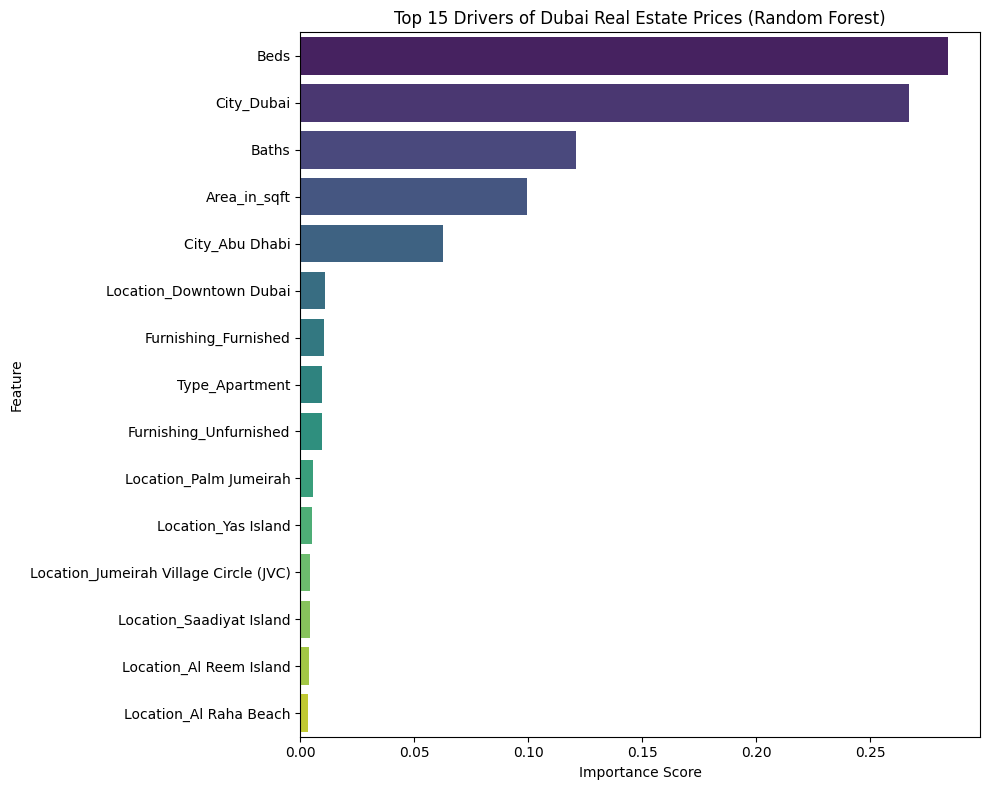

In [17]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Drivers of Dubai Real Estate Prices (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [18]:
print(importance_df.head(5))
import joblib
joblib.dump(model_pipeline,'price_prediction_model.pkl')
joblib.dump(list(x.columns),'model_columns.pkl')
x_train

          Feature  Importance
0            Beds    0.283901
1      City_Dubai    0.266998
2           Baths    0.120909
3    Area_in_sqft    0.099676
4  City_Abu Dhabi    0.062754


,Beds,Baths,Type,Area_in_sqft,Furnishing,Location,City
12150,4,6,Villa,5600,Unfurnished,Mohammed Bin Zayed City,Abu Dhabi
35821,1,2,Apartment,636,Unfurnished,Jumeirah Village Circle (JVC),Dubai
67798,4,5,Villa,4800,Unfurnished,Muwaileh,Sharjah
35387,2,2,Apartment,1147,Unfurnished,Jumeirah Village Circle (JVC),Dubai
34464,1,2,Apartment,980,Unfurnished,Discovery Gardens,Dubai
...,...,...,...,...,...,...,...
38123,0,2,Apartment,501,Furnished,Al Furjan,Dubai
6365,1,2,Apartment,1150,Unfurnished,Navy Gate,Abu Dhabi
56607,2,2,Apartment,1550,Unfurnished,Bur Dubai,Dubai
868,3,4,Apartment,1000,Unfurnished,Madinat Al Riyadh,Abu Dhabi


In [ ]:
z
df=pd.read_csv('dubai_properties.csv')
print(df.info())
print(df.describe())
df_filtered=df[['Rent', 'Beds', 'Baths', 'Type', 'Area_in_sqft', 'Furnishing', 'Location', 'City',]].copy()
df_filtered=df_filtered[df_filtered['Rent']>0]
df_filtered = df_filtered.dropna(subset=['Beds', 'Baths', 'Type', 'Area_in_sqft', 'Furnishing', 'Location', 'City'])
df_filtered
lower_limit=df_filtered['Rent'].quantile(0.01)
upper_limit=df_filtered['Rent'].quantile(0.99)
df_filtered=df_filtered[(df_filtered['Rent']>=lower_limit) & (df_filtered['Rent']<=upper_limit)]
df_filtered.info()
lower_limit=df_filtered['Area_in_sqft'].quantile(0.01)
upper_limit=df_filtered['Area_in_sqft'].quantile(0.99)
df_filtered=df_filtered[(df_filtered['Area_in_sqft']>=lower_limit) & (df_filtered['Area_in_sqft']<=upper_limit)]
df_filtered.info()
df_filtered
y=np.log(df_filtered['Rent'])
x=df_filtered.drop(columns=['Rent'])
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),['Beds','Baths','Area_in_sqft']),
        ('cat',OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Type','Furnishing','Location','City'])
    ]
)
model_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1))
])
model_pipeline.fit(x_train,y_train)
y_pred=np.exp(model_pipeline.predict(x_test))

y_test_actual=np.exp(y_test)

print(f"R2 SCORE: {r2_score(y_test_actual, y_pred)}")
print(f"MAE : {mean_absolute_error(y_pred,y_test_actual)}")
# Calculate the percentage error for every row
percentage_errors = np.abs((y_test_actual - y_pred) / y_test_actual) * 100

print(f"Median Error Percentage: {np.median(percentage_errors):.2f}%")
results_df = pd.DataFrame({'Actual': y_test_actual, 'Predicted': y_pred})
results_df
results_df['difference']=results_df['Predicted']-results_df['Actual']
results_df
# Let's inspect the exact row where the AI failed the hardest
print("--- The AI's Biggest Miss ---")
print(df_filtered.loc[31102])
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the actual model and the preprocessor from your pipeline
rf_model = model_pipeline.named_steps['model']
preprocessor = model_pipeline.named_steps['preprocessor']

# 2. Get the original numerical column names
num_cols = ['Beds', 'Baths', 'Area_in_sqft']

# 3. Extract the new categorical column names created by the OneHotEncoder
# We access the 'cat' transformer from the preprocessor step
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(['Type', 'Furnishing', 'Location', 'City'])

# 4. Combine them into one master list of features
all_features = num_cols + list(cat_cols)

# 5. Get the importance scores from the Random Forest
importances = rf_model.feature_importances_

# 6. Create a DataFrame and sort it
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 7. Plot the Top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Drivers of Dubai Real Estate Prices (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Print the top 5 to the console
print(importance_df.head(5))
import joblib
joblib.dump(model_pipeline,'price_prediction_model.pkl')
joblib.dump(list(x.columns),'model_columns.pkl')
x_train

In [21]:
from sklearn.model_selection import RandomizedSearchCV

# ── Hyperparameter search space ───────────────────────────────────────────────
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 15, 20, 25, None],
    'model__min_samples_leaf': [2, 4, 6, 8],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2', 0.5]
}

# ── Random search with cross validation ──────────────────────────────────────
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_grid,
    n_iter=30,           # tries 30 random combinations
    cv=5,                # 5-fold cross validation on each
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2            # prints progress so you can see it working
)

random_search.fit(x_train, y_train)

# ── Use the best model ────────────────────────────────────────────────────────
model_pipeline = random_search.best_estimator_

print("Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best cross-validated R2: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:
  model__n_estimators: 300
  model__min_samples_split: 2
  model__min_samples_leaf: 4
  model__max_features: 0.5
  model__max_depth: None
Best cross-validated R2: 0.9357


In [36]:
y_pred = np.exp(model_pipeline.predict(x_test))
y_test_actual = np.exp(y_test)

print(f"R2 Score:        {r2_score(y_test_actual, y_pred):.4f}")
print(f"MAE:             {mean_absolute_error(y_test_actual, y_pred):,.0f} AED")

mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100
median_error = np.median(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100
print(f"MAPE:            {mape:.2f}%")
print(f"Median Error:    {median_error:.2f}%")

R2 Score:        0.6491
MAE:             34,000 AED
MAPE:            24.27%
Median Error:    19.73%


In [23]:
errors = np.abs((y_test_actual - y_pred) / y_test_actual) * 100
print(f"% of predictions within 10%: {(errors < 10).mean() * 100:.1f}%")
print(f"% of predictions within 20%: {(errors < 20).mean() * 100:.1f}%")
print(f"% of predictions within 30%: {(errors < 30).mean() * 100:.1f}%")

# Find the worst predictions
results_df = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted': y_pred,
    'Error_%': errors
}).sort_values('Error_%', ascending=False)

print("\nTop 10 worst predictions:")
print(results_df.head(10))

% of predictions within 10%: 51.5%
% of predictions within 20%: 77.8%
% of predictions within 30%: 89.6%

Top 10 worst predictions:
         Actual      Predicted     Error_%
30508   23000.0  153055.156382  565.457202
60677   80400.0  288850.395659  259.266661
60091  131000.0  401851.146916  206.756601
11240   65000.0  181895.079550  179.838584
62866   75000.0  206272.131586  175.029509
39154  165000.0  450606.739873  173.094994
56563   48000.0  129532.928737  169.860268
32331   17500.0   45642.869359  160.816396
32534   17888.0   45642.869359  155.159153
32471   75000.0  189104.596607  152.139462


In [26]:
# Check what these properties actually are
worst_indices = results_df.head(10).index
print(x_test.loc[worst_indices])

       Beds  Baths       Type  Area_in_sqft   Furnishing  \
30508     1      2  Apartment           787  Unfurnished   
60677     2      2  Apartment          1663    Furnished   
60091     2      2  Apartment          1390  Unfurnished   
11240     1      2  Apartment          1250    Furnished   
62866     3      3  Apartment          2100  Unfurnished   
39154     5      2      Villa          8935  Unfurnished   
56563     1      2  Apartment          1086    Furnished   
32331     0      2  Apartment           450  Unfurnished   
32534     0      2  Apartment           450  Unfurnished   
32471     2      2  Apartment          2167  Unfurnished   

                             Location       City  
30508                   Palm Jumeirah      Dubai  
60677                  Downtown Dubai      Dubai  
60091  Jumeirah Beach Residence (JBR)      Dubai  
11240                 Saadiyat Island  Abu Dhabi  
62866                       Al Qusais      Dubai  
39154                       Al Ba

In [29]:
# 1. Load & select columns
df_filtered = df[['Rent', 'Beds', 'Baths', 'Type', 'Area_in_sqft',
                   'Furnishing', 'Location', 'City']].copy()

# 2. Remove zero rents and nulls
df_filtered = df_filtered[df_filtered['Rent'] > 0]
df_filtered = df_filtered.dropna(subset=['Beds', 'Baths', 'Type', 'Area_in_sqft',
                                          'Furnishing', 'Location', 'City'])

# 3. Fix 1 — handle studios (0 beds)
df_filtered['Beds'] = df_filtered['Beds'].replace(0, 0.5)

# 4. Fix 2 — remove duplicates
df_filtered = df_filtered.drop_duplicates(subset=['Beds', 'Baths', 'Type', 'Area_in_sqft',
                                                    'Furnishing', 'Location', 'City', 'Rent'])
print(f"After deduplication: {len(df_filtered)} rows")

# 5. Fix 3 — clip outliers per city
def clip_outliers_by_city(df, col, lower_q=0.02, upper_q=0.98):
    def clip_group(group):
        lower = group[col].quantile(lower_q)
        upper = group[col].quantile(upper_q)
        return group[(group[col] >= lower) & (group[col] <= upper)]
    return df.groupby('City', group_keys=False).apply(clip_group)

df_filtered = clip_outliers_by_city(df_filtered, 'Rent')
df_filtered = clip_outliers_by_city(df_filtered, 'Area_in_sqft')
print(f"After per-city clipping: {len(df_filtered)} rows")

# 6. Rare location filter
location_counts = df_filtered['Location'].value_counts()
rare_locations = location_counts[location_counts < 10].index
df_filtered = df_filtered[~df_filtered['Location'].isin(rare_locations)]
print(f"After removing rare locations: {len(df_filtered)} rows")

# ... rest of your training code stays the same

After deduplication: 61832 rows
After per-city clipping: 57280 rows
After removing rare locations: 56774 rows


/var/folders/ry/9t89fzt910132vr_zkzg0jz40000gn/T/ipykernel_18637/3019043734.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('City', group_keys=False).apply(clip_group)
/var/folders/ry/9t89fzt910132vr_zkzg0jz40000gn/T/ipykernel_18637/3019043734.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('City', group_keys=False).apply(clip_group)


In [37]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=4,
        min_samples_split=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

model_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
# Add this right after your cleaning steps, before training
print(f"After deduplication: {len(df_filtered)} rows")
print(f"After adaptive clipping: {len(df_filtered)} rows")
print(f"After rare location filter: {len(df_filtered)} rows")
print(f"\nCity counts:\n{df_filtered['City'].value_counts()}")
print(f"\nRent min: {df_filtered['Rent'].min()}")
print(f"Rent max: {df_filtered['Rent'].max()}")

After deduplication: 52872 rows
After adaptive clipping: 52872 rows
After rare location filter: 52872 rows

City counts:
City
Dubai             24675
Abu Dhabi         17046
Sharjah            6431
Ajman              3277
Al Ain              842
Ras Al Khaimah      601
Name: count, dtype: int64

Rent min: 15000
Rent max: 600000


In [33]:
# Fix 1 — Remove Umm Al Quwain (too few listings for a reliable model)
df_filtered = df_filtered[df_filtered['City'] != 'Umm Al Quwain']

# Fix 2 — Use gentler clipping for smaller cities
def clip_outliers_by_city(df, col):
    def clip_group(group):
        # Larger cities get tighter clipping, smaller cities get looser
        if len(group) >= 5000:
            lower_q, upper_q = 0.02, 0.98
        elif len(group) >= 1000:
            lower_q, upper_q = 0.01, 0.99
        else:
            lower_q, upper_q = 0.005, 0.995  # very gentle for small cities
        lower = group[col].quantile(lower_q)
        upper = group[col].quantile(upper_q)
        return group[(group[col] >= lower) & (group[col] <= upper)]
    return df.groupby('City', group_keys=False).apply(clip_group)

df_filtered = clip_outliers_by_city(df_filtered, 'Rent')
df_filtered = clip_outliers_by_city(df_filtered, 'Area_in_sqft')
print(f"After adaptive clipping: {len(df_filtered)} rows")

After adaptive clipping: 52888 rows


/var/folders/ry/9t89fzt910132vr_zkzg0jz40000gn/T/ipykernel_18637/2739294693.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('City', group_keys=False).apply(clip_group)
/var/folders/ry/9t89fzt910132vr_zkzg0jz40000gn/T/ipykernel_18637/2739294693.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('City', group_keys=False).apply(clip_group)
